# 2022-C题学习指南（2）：统计分析与假设检验

**主题：古代玻璃制品的成分分析与鉴别**

本 notebook 直接读取《2022-C题学习指南（1）：数据预处理》导出的标准数据，讲解并练习 2022-C 题所需的基础统计分析。

方法范围以 Peter Bruce、Andrew Bruce 和 Peter Gedeck 的 *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python*（第二版）为依据，只保留书中介绍或明确提到的常用内容：QQ 图、两样本 t 检验、Welch t 检验、置换检验、卡方检验、Fisher 精确检验、Pearson/Spearman 相关和 Bonferroni 多重比较校正。

前八道练习分别训练一个知识点，最后三道综合练习直接支持赛题问题 1 和问题 4 的作答。

## Goal

完成本章后，你应该能够：

1. 把赛题描述翻译成可检验的原假设与备择假设；
2. 仿照实验 5 使用两样本 t 检验计算 p 值；
3. 使用 QQ 图观察分布形态，并理解长尾数据对均值检验的影响；
4. 使用 Welch t 检验和置换检验比较两个独立组；
5. 使用卡方检验或 Fisher 精确检验分析分类变量；
6. 使用 Pearson 和 Spearman 系数分析成分关系；
7. 认识多重检验造成的 alpha 膨胀，并使用书中介绍的 Bonferroni 方法；
8. 将多个基础方法组合起来回答赛题问题。

## Setup

推荐 Python 3.10 或更高版本。缺少依赖时可在终端执行：

```bash
pip install pandas numpy matplotlib scipy nbformat termcolor
```

### 本章的数据依赖

请先运行 [2022-C题学习指南-01-数据预处理.ipynb](./2022-C题学习指南-01-数据预处理.ipynb) 的“导出供后续章节复用的预处理数据”单元。它会在 `data/processed/` 生成三份 CSV。本章只读取这些结果，因此预处理规则只有一个来源；调整第一章规则后，重新导出即可同步所有后续分析。

下面的初始化代码定位案例目录并检查三个预处理文件是否存在。

In [1]:
from itertools import combinations
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang SC", "Microsoft YaHei", "SimHei", "DejaVu Sans"
]

candidate_dirs = [Path.cwd(), *Path.cwd().parents]
CASE_DIR = next(
    (path for path in candidate_dirs if (path / "data" / "processed").exists()),
    Path.cwd(),
)
PROCESSED_DIR = CASE_DIR / "data" / "processed"
TESTS_DIR = CASE_DIR / "tests"
NOTEBOOK_FILE = CASE_DIR / "2022-C题学习指南-02-统计分析与假设检验.ipynb"

BASIC_FILE = PROCESSED_DIR / "2022c-文物信息.csv"
VALID_SAMPLES_FILE = PROCESSED_DIR / "2022c-有效采样点.csv"
ARTIFACT_SURFACE_FILE = PROCESSED_DIR / "2022c-文物采样面.csv"
required_files = [BASIC_FILE, VALID_SAMPLES_FILE, ARTIFACT_SURFACE_FILE]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    missing_text = "\n".join(f"- {path}" for path in missing_files)
    raise FileNotFoundError(
        "缺少第一章导出的预处理文件。请先运行数据预处理 notebook 的导出单元：\n"
        + missing_text
    )

print("案例目录：", CASE_DIR)
print("预处理数据目录：", PROCESSED_DIR)

Matplotlib is building the font cache; this may take a moment.


案例目录： /Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例
预处理数据目录： /Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例/data/processed


### 外部自动测试

与实验 1 和数据预处理 notebook 一致，评分逻辑与学生作答分离：

- `tests/base_test_suite.py`：收集标有 `# GRADED FUNCTION:` 的函数并汇总成绩；
- `tests/test_suite_2022c_hypothesis_testing.py`：使用真实附件数据验证本章十一道练习；
- 每个练习后的测试只报告通过、未完成或失败，不在 notebook 中暴露答案。

修改测试文件后重新运行下面单元，`reload` 会加载最新版本。

In [2]:
if str(TESTS_DIR) not in sys.path:
    sys.path.insert(0, str(TESTS_DIR))

import base_test_suite
import test_suite_2022c_hypothesis_testing

importlib.reload(base_test_suite)
importlib.reload(test_suite_2022c_hypothesis_testing)

from test_suite_2022c_hypothesis_testing import TestSuite2022CHypothesisTesting

testsuite = TestSuite2022CHypothesisTesting()
print("统计分析测试套件已加载，共 11 道练习。")

统计分析测试套件已加载，共 11 道练习。


## Steps

## 1. 读取第一章的预处理结果

第一章已经完成本题最容易出错的数据工作：

- 保护 `01` 等文物编号的前导零；
- 把“文物采样点”拆为“文物编号”和“采样点”；
- 将成分空白按题意作为未检出值处理；
- 按 85%～105% 的总量范围标记并筛选有效样本；
- 合并表单 1，并解析普通、未风化和严重风化采样面；
- 将同一文物、同一采样面状态的重复记录汇总到统一分析粒度。

本章只加载以下数据产品：

- `basic`：一行一件文物，用于类型、纹饰、颜色与表面风化的列联分析；
- `valid_samples`：一行一个有效采样点，用于同一文物不同部位的配对；
- `artifact_surface`：一行是一件文物的一种采样面状态，用于独立组比较和相关分析。

In [3]:
# 只读取第一章的标准输出，不再读取或清洗原始Excel。
basic = pd.read_csv(BASIC_FILE, dtype={"文物编号": "string"})
valid_samples = pd.read_csv(
    VALID_SAMPLES_FILE,
    dtype={"文物编号": "string", "文物采样点": "string"},
)
artifact_surface = pd.read_csv(
    ARTIFACT_SURFACE_FILE,
    dtype={"文物编号": "string"},
)
component_columns = list(artifact_surface.columns[3:])

overview = pd.DataFrame(
    {
        "数据层": ["basic", "valid_samples", "artifact_surface"],
        "来源文件": [BASIC_FILE.name, VALID_SAMPLES_FILE.name, ARTIFACT_SURFACE_FILE.name],
        "一行表示": ["一件文物", "一个有效采样点", "一件文物的一种采样面状态"],
        "行数": [len(basic), len(valid_samples), len(artifact_surface)],
    }
)
display(overview)
display(artifact_surface.groupby(["类型", "采样面状态"]).size().rename("n").to_frame())

,数据层,来源文件,一行表示,行数
0,basic,2022c-文物信息.csv,一件文物,58
1,valid_samples,2022c-有效采样点.csv,一个有效采样点,67
2,artifact_surface,2022c-文物采样面.csv,一件文物的一种采样面状态,61


n
类型 采样面状态    
铅钡 严重风化    3
   无风化    21
   风化     21
高钾 无风化    10
   风化      6

### 1.1 从研究问题到统计检验：先复习最简单的 t 检验

实验 5 已经学习过两独立样本 t 检验。它比较两个相互独立总体的均值：

$$H_0:\mu_A=\mu_B,\qquad H_1:\mu_A\ne\mu_B.$$

在等方差版本中，先计算合并方差

$$s_p^2=\frac{(n_A-1)s_A^2+(n_B-1)s_B^2}{n_A+n_B-2},$$

再计算

$$t=\frac{\bar{x}_A-\bar{x}_B}{s_p\sqrt{1/n_A+1/n_B}},\qquad df=n_A+n_B-2.$$

Python 使用 `stats.ttest_ind(group_a, group_b, equal_var=True)` 同时计算 t 统计量和 p 值。p 值不是预先给出的标签，而是在 $H_0$ 成立的前提下，由样本差异及其抽样误差计算得到的。

若 $p<\alpha$，拒绝 $H_0$；否则只能说“不能拒绝 $H_0$”。p 值不等于 $H_0$ 为真的概率，也不表示差异有多大，因此还要报告均值差等描述量。

等方差 t 检验要求两组独立、因变量连续、总体近似正态且方差相等。本节先复现实验 5 的基础方法；后面会学习诊断方法和不要求方差相等的 Welch t 检验。

In [4]:
# 教师示例：沿用实验5的写法，比较铅钡玻璃无风化与风化采样面的PbO均值。
pbba_two_surfaces = artifact_surface.loc[
    (artifact_surface["类型"] == "铅钡")
    & artifact_surface["采样面状态"].isin(["无风化", "风化"])
]
lead_no_weathering = pbba_two_surfaces.loc[
    pbba_two_surfaces["采样面状态"] == "无风化", "氧化铅(PbO)"
].dropna()
lead_weathered = pbba_two_surfaces.loc[
    pbba_two_surfaces["采样面状态"] == "风化", "氧化铅(PbO)"
].dropna()

t_statistic, p_value = stats.ttest_ind(
    lead_no_weathering,
    lead_weathered,
    equal_var=True,
)
degrees_of_freedom = len(lead_no_weathering) + len(lead_weathered) - 2
print(f"无风化均值：{lead_no_weathering.mean():.3f}")
print(f"风化均值：{lead_weathered.mean():.3f}")
print(f"均值差：{lead_no_weathering.mean() - lead_weathered.mean():.3f}")
print(f"t={t_statistic:.4f}, df={degrees_of_freedom}, p={p_value:.6g}")
print("是否拒绝H0：", p_value < 0.05)

无风化均值：21.356
风化均值：43.202
均值差：-21.846
t=-6.9492, df=40, p=2.20758e-08
是否拒绝H0： True


### 练习1：用最简单的 t 检验计算 p 值

补全 `simple_independent_t_test`。练习比较**无风化采样面中高钾与铅钡玻璃的 SiO2 均值**，不直接提供 p 值；你需要像实验 5 一样：

1. 根据 `group_column` 和两个组标签筛选数值并删除缺失值；
2. 计算两组样本量、均值、样本标准差之差；
3. 调用 `stats.ttest_ind(group_a, group_b, equal_var=True)`；
4. 计算自由度 `n_a + n_b - 2`；
5. 根据 `p_value < alpha` 判断是否显著。

返回字典，包含 `n_a`、`n_b`、`mean_a`、`mean_b`、`mean_difference`、`sd_difference`、`dof`、`t_statistic`、`p_value`、`is_significant`。

In [5]:
# UNQ_C1（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: simple_independent_t_test
def simple_independent_t_test(
    data, value_column, group_column, group_a, group_b, alpha=0.05
):
    """仿照实验5，完成等方差两独立样本t检验并由数据计算p值。"""
    # 你的代码从这里开始
    # 第1步：根据group_column分别筛选group_a和group_b，并删除数值缺失。
    values_a = ...
    values_b = ...

    # 第2步：计算两个样本量、两个均值以及“A减B”的均值差。
    n_a, n_b = ...
    mean_a, mean_b = ...
    mean_difference = ...

    # 第3步：计算两个样本标准差之差；pandas的std默认ddof=1。
    sd_difference = ...

    # 第4步：仿照实验5，使用equal_var=True执行等方差独立样本t检验。
    t_statistic, p_value = ...

    # 第5步：计算自由度n_a+n_b-2，并根据p_value<alpha判断显著性。
    dof = ...
    is_significant = ...

    # 第6步：按题目要求组织返回字段。
    result = {
        "n_a": n_a, "n_b": n_b,
        "mean_a": mean_a, "mean_b": mean_b,
        "mean_difference": mean_difference,
        "sd_difference": sd_difference,
        "dof": dof, "t_statistic": t_statistic,
        "p_value": p_value, "is_significant": is_significant,
    }
    # 你的代码到这里结束

    return result

In [6]:
testsuite.test_simple_independent_t_test(simple_independent_t_test)

测试失败 test_simple_independent_t_test：cannot unpack non-iterable ellipsis object


## 2. 两个分类变量：卡方独立性检验

赛题问题 1 要分析玻璃类型、纹饰、颜色和表面风化之间的关系。这些是分类变量，适合从列联表开始。

设观测频数为 $O_{ij}$。在“行变量与列变量独立”的原假设下，期望频数为

$$E_{ij}=\frac{(\text{第 }i\text{ 行总数})(\text{第 }j\text{ 列总数})}{n}.$$

Pearson 卡方统计量为

$$\chi^2=\sum_i\sum_j\frac{(O_{ij}-E_{ij})^2}{E_{ij}},$$

自由度为 $(r-1)(c-1)$。统计量越大，说明观测频数与“独立”假设下的期望频数差异越大。

使用卡方近似时应检查观测是否相互独立以及期望频数是否过小。书中指出，当计数很小时可改用 Fisher 精确检验。

In [7]:
# 教师示例：纹饰与表面风化是否独立？
ornament_table = pd.crosstab(basic["纹饰"], basic["表面风化"])
ornament_test = stats.chi2_contingency(ornament_table)
ornament_expected = pd.DataFrame(
    ornament_test.expected_freq,
    index=ornament_table.index,
    columns=ornament_table.columns,
)
display(Markdown("**观测频数**"))
display(ornament_table)
display(Markdown("**独立假设下的期望频数**"))
display(ornament_expected.round(2))
print(f"chi2={ornament_test.statistic:.4f}, df={ornament_test.dof}, p={ornament_test.pvalue:.4f}")
print("最小期望频数：", ornament_expected.to_numpy().min())

**观测频数**

表面风化,无风化,风化
纹饰,,
A,11,11
B,0,6
C,13,17


**独立假设下的期望频数**

表面风化,无风化,风化
纹饰,,
A,9.10,12.90
B,2.48,3.52
C,12.41,17.59


chi2=4.9565, df=2, p=0.0839
最小期望频数： 2.4827586206896552


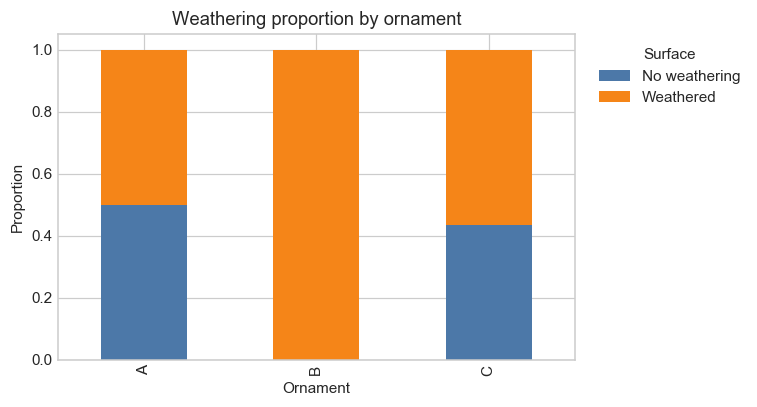

In [8]:
ornament_prop = ornament_table.div(ornament_table.sum(axis=1), axis=0)
ornament_prop.columns = ["No weathering", "Weathered"]
ax = ornament_prop.plot(
    kind="bar", stacked=True, figsize=(7, 3.8), color=["#4C78A8", "#F58518"]
)
ax.set(title="Weathering proportion by ornament", xlabel="Ornament", ylabel="Proportion")
ax.legend(title="Surface", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 练习2：封装卡方独立性检验

补全 `chi_square_independence`：建立列联表，运行 `stats.chi2_contingency`，返回观测频数、期望频数、统计量、p 值、自由度、最小期望频数和显著性判定。测试使用“类型 × 表面风化”。

In [9]:
# UNQ_C2（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: chi_square_independence
def chi_square_independence(data, row_column, column_column, alpha=0.05):
    """对两个分类变量执行Pearson卡方独立性检验。"""
    # 你的代码从这里开始
    # 第1步：使用pd.crosstab建立观测频数表。
    table = ...
    # 第2步：调用stats.chi2_contingency。
    chi2_result = ...
    statistic, p_value, dof = ...
    # 第3步：将期望频数转换为具有相同行列标签的DataFrame。
    expected = ...
    # 第4步：求最小期望频数，并根据p_value<alpha判断显著性。
    min_expected = ...
    is_significant = ...
    # 第5步：组织返回结果。
    result = {
        "table": table, "expected": expected, "statistic": statistic,
        "p_value": p_value, "dof": dof, "min_expected": min_expected,
        "is_significant": is_significant,
    }
    # 你的代码到这里结束
    return result

In [10]:
testsuite.test_chi_square_independence(chi_square_independence)

测试失败 test_chi_square_independence：cannot unpack non-iterable ellipsis object


## 3. 小计数的 2×2 表：Fisher 精确检验

卡方检验依赖大样本近似。对于稀疏的 2×2 表，书中建议使用 Fisher 精确检验。它在行、列边际固定的条件下，通过超几何分布计算当前表及同等或更极端表出现的概率。

SciPy 的 `stats.fisher_exact` 返回优势比和 p 值。优势比的方向依赖行列顺序，因此建表后必须显式 `reindex`。结论仍需同时展示原始频数，避免只报告一个 p 值。

In [11]:
# 教师示例：比较“类型 × 表面风化”的卡方与Fisher结果。
fisher_table = pd.crosstab(basic["类型"], basic["表面风化"]).reindex(
    index=["高钾", "铅钡"], columns=["无风化", "风化"], fill_value=0
)
fisher_result = stats.fisher_exact(fisher_table.to_numpy(), alternative="two-sided")
chi_result = stats.chi2_contingency(fisher_table)
display(fisher_table)
print(f"Fisher: odds ratio={fisher_result.statistic:.3f}, p={fisher_result.pvalue:.4f}")
print(f"Chi-square: chi2={chi_result.statistic:.3f}, p={chi_result.pvalue:.4f}")

表面风化,无风化,风化
类型,,
高钾,12,6
铅钡,12,28


Fisher: odds ratio=4.667, p=0.0113
Chi-square: chi2=5.452, p=0.0195


### 练习3：实现可控行列顺序的 Fisher 检验

补全 `fisher_exact_independence`：建立列联表，按指定顺序重排为 2×2 表，调用 `stats.fisher_exact`，并返回优势比、p 值和显著性判定。测试从真实颜色列构造“浅蓝/非浅蓝”。

In [12]:
# UNQ_C3（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: fisher_exact_independence
def fisher_exact_independence(
    data, row_column, column_column, row_order, column_order,
    alternative="two-sided", alpha=0.05,
):
    """对按指定顺序构造的2×2列联表执行Fisher精确检验。"""
    # 你的代码从这里开始
    # 第1步：使用pd.crosstab建立观测频数表。
    table = ...
    # 第2步：按row_order和column_order重排，缺少组合填0。
    table = ...
    # 第3步：调用stats.fisher_exact。
    fisher_result = ...
    odds_ratio, p_value = ...
    # 第4步：判断显著性并组织返回结果。
    is_significant = ...
    result = {
        "table": table, "odds_ratio": odds_ratio,
        "p_value": p_value, "is_significant": is_significant,
    }
    # 你的代码到这里结束
    return result

In [13]:
testsuite.test_fisher_exact_independence(fisher_exact_independence)

测试失败 test_fisher_exact_independence：cannot unpack non-iterable ellipsis object


## 4. 正态分布与 QQ 图

书中使用 QQ 图判断样本分布与正态分布的接近程度。它将排序后的样本值与相同秩位置的理论正态分位数配对：点越接近参考直线，样本分布越接近正态；两端明显偏离通常提示偏态或长尾。

SciPy 的 `stats.probplot(values, dist="norm")` 返回理论分位数、排序后的观测值，以及拟合直线的斜率、截距和相关程度。QQ 图是一种图形诊断，不应把“点大致靠近直线”解释为对正态性的证明。

In [14]:
# 教师示例：铅钡玻璃风化前后SiO2的QQ图。
lead_barium = artifact_surface.loc[
    (artifact_surface["类型"] == "铅钡")
    & artifact_surface["采样面状态"].isin(["无风化", "风化"])
]
silica_no = lead_barium.loc[lead_barium["采样面状态"] == "无风化", "二氧化硅(SiO2)"].dropna()
silica_weathered = lead_barium.loc[lead_barium["采样面状态"] == "风化", "二氧化硅(SiO2)"].dropna()
qq_no = stats.probplot(silica_no, dist="norm")
qq_weathered = stats.probplot(silica_weathered, dist="norm")
print(f"No weathering: n={len(silica_no)}, QQ r={qq_no[1][2]:.4f}")
print(f"Weathered: n={len(silica_weathered)}, QQ r={qq_weathered[1][2]:.4f}")

No weathering: n=21, QQ r=0.9837
Weathered: n=21, QQ r=0.9557


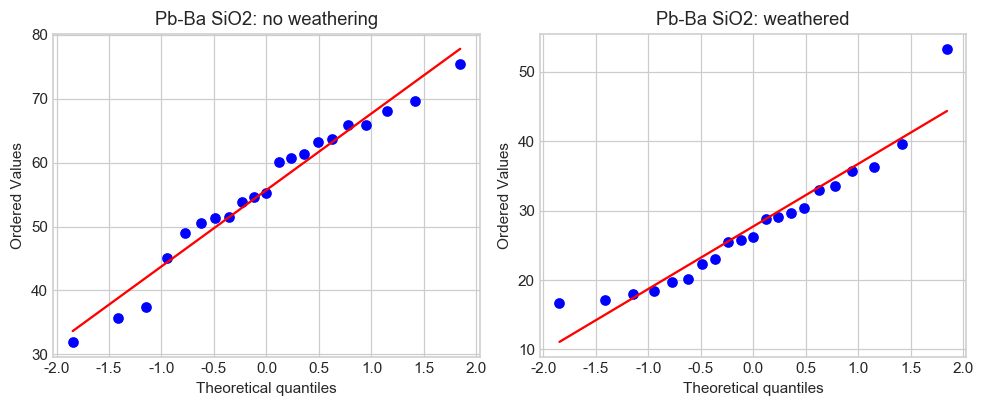

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
stats.probplot(silica_no, dist="norm", plot=axes[0])
stats.probplot(silica_weathered, dist="norm", plot=axes[1])
axes[0].set_title("Pb-Ba SiO2: no weathering")
axes[1].set_title("Pb-Ba SiO2: weathered")
plt.tight_layout()
plt.show()

### 练习4：准备两组 QQ 图数据

补全 `prepare_qq_plot_data`。分别筛选两组并调用 `stats.probplot`，将理论分位数和排序观测值整理成两个 DataFrame，同时返回每组拟合直线参数。练习使用 PbO，与示例的 SiO2 不同。

In [16]:
# UNQ_C4（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: prepare_qq_plot_data
def prepare_qq_plot_data(data, value_column, group_column, group_a, group_b):
    """为两个独立组准备正态QQ图数据。"""
    # 你的代码从这里开始
    # 第1步：分别提取两个组的非缺失数值。
    values_a = ...
    values_b = ...
    # 第2步：分别调用stats.probplot，dist设置为'norm'。
    probplot_a = ...
    probplot_b = ...
    # 第3步：把理论分位数和排序观测值整理成两列DataFrame。
    qq_a = ...
    qq_b = ...
    # 第4步：从probplot结果中取得斜率、截距和r。
    slope_a, intercept_a, r_a = ...
    slope_b, intercept_b, r_b = ...
    # 第5步：组织返回结果。
    result = {
        "n_a": len(values_a), "n_b": len(values_b),
        "qq_a": qq_a, "qq_b": qq_b,
        "slope_a": slope_a, "intercept_a": intercept_a, "r_a": r_a,
        "slope_b": slope_b, "intercept_b": intercept_b, "r_b": r_b,
    }
    # 你的代码到这里结束
    return result

In [17]:
testsuite.test_prepare_qq_plot_data(prepare_qq_plot_data)

测试失败 test_prepare_qq_plot_data：cannot unpack non-iterable ellipsis object


## 5. 两个独立组：Welch t 检验

书中的 Python 示例使用 `stats.ttest_ind(..., equal_var=False)`，即 Welch 两样本 t 检验。它比较两个独立总体的均值，不要求两组总体方差相等：

$$t=\frac{\bar{x}_A-\bar{x}_B}{\sqrt{s_A^2/n_A+s_B^2/n_B}}.$$

自由度由 Welch-Satterthwaite 近似计算，通常不是整数。报告结果时至少给出两组样本量、均值、均值差、t 统计量、自由度和 p 值。均值差体现实际变化方向，p 值只说明与零假设的不相容程度。

In [18]:
# 教师示例：铅钡玻璃无风化与风化采样面的SiO2均值比较。
welch_silica = stats.ttest_ind(silica_no, silica_weathered, equal_var=False)
print(f"无风化均值={silica_no.mean():.2f}, 风化均值={silica_weathered.mean():.2f}")
print(f"均值差={silica_no.mean()-silica_weathered.mean():.2f}")
print(f"Welch t={welch_silica.statistic:.3f}, df={welch_silica.df:.2f}, p={welch_silica.pvalue:.3g}")

无风化均值=55.73, 风化均值=27.73
均值差=28.00
Welch t=8.764, df=37.66, p=1.26e-10


### 练习5：实现 Welch 两样本 t 检验

补全 `welch_t_test`：提取两组数据，调用 `stats.ttest_ind(..., equal_var=False)`，返回样本量、均值、均值差、t 统计量、自由度、p 值和显著性判定。练习使用高钾玻璃的 K2O。

In [19]:
# UNQ_C5（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: welch_t_test
def welch_t_test(data, value_column, group_column, group_a, group_b, alpha=0.05):
    """执行Welch两独立样本t检验。"""
    # 你的代码从这里开始
    # 第1步：提取两组非缺失数值。
    values_a = ...
    values_b = ...
    # 第2步：计算样本量、均值和A减B的均值差。
    n_a, n_b = ...
    mean_a, mean_b = ...
    mean_difference = ...
    # 第3步：调用stats.ttest_ind并设置equal_var=False。
    test_result = ...
    # 第4步：提取统计量、p值、自由度并判断显著性。
    statistic, p_value, dof = ...
    is_significant = ...
    # 第5步：组织返回结果。
    result = {
        "n_a": n_a, "n_b": n_b, "mean_a": mean_a, "mean_b": mean_b,
        "mean_difference": mean_difference, "statistic": statistic,
        "p_value": p_value, "dof": dof, "is_significant": is_significant,
    }
    # 你的代码到这里结束
    return result

In [20]:
testsuite.test_welch_t_test(welch_t_test)

测试失败 test_welch_t_test：cannot unpack non-iterable ellipsis object


## 6. 不依赖 t 分布近似：置换检验

书中把置换检验作为数据科学中理解假设检验的重要方法。原假设认为两组标签可以互换。算法如下：

1. 计算观测均值差；
2. 合并两组数值并随机打乱；
3. 按原样本量切成两个置换组并计算均值差；
4. 重复很多次，形成零假设下的参考分布；
5. 双侧 p 值是置换差绝对值不小于观测差绝对值的比例。

固定 `random_state` 可以使教学结果可复现。使用有限次数模拟时，本练习采用 $(k+1)/(B+1)$，避免 p 值恰好为 0。

In [21]:
# 教师示例：铅钡玻璃PbO的双侧置换均值检验。
lead_no = lead_barium.loc[lead_barium["采样面状态"] == "无风化", "氧化铅(PbO)"].dropna().to_numpy()
lead_weathered = lead_barium.loc[lead_barium["采样面状态"] == "风化", "氧化铅(PbO)"].dropna().to_numpy()
observed_difference = lead_no.mean() - lead_weathered.mean()
combined = np.concatenate([lead_no, lead_weathered])
rng = np.random.default_rng(42)
permuted_differences = []
for _ in range(5000):
    shuffled = rng.permutation(combined)
    permuted_differences.append(
        shuffled[:len(lead_no)].mean() - shuffled[len(lead_no):].mean()
    )
permuted_differences = np.asarray(permuted_differences)
extreme_count = np.sum(np.abs(permuted_differences) >= abs(observed_difference))
permutation_p = (extreme_count + 1) / (len(permuted_differences) + 1)
print(f"观测均值差={observed_difference:.3f}, permutation p={permutation_p:.5f}")

观测均值差=-21.846, permutation p=0.00020


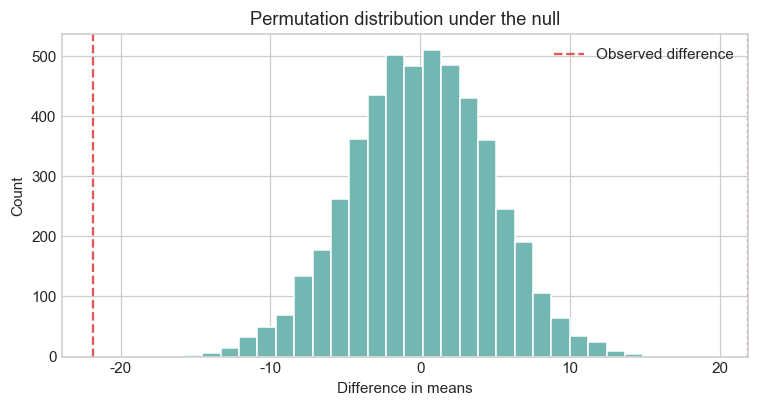

In [22]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(permuted_differences, bins=30, color="#72B7B2", edgecolor="white")
ax.axvline(observed_difference, color="#E45756", linestyle="--", label="Observed difference")
ax.axvline(-observed_difference, color="#E45756", linestyle=":")
ax.set(title="Permutation distribution under the null", xlabel="Difference in means", ylabel="Count")
ax.legend()
plt.tight_layout()
plt.show()

### 练习6：实现双侧置换均值检验

补全 `permutation_mean_test`。练习使用高钾玻璃的 SiO2；必须使用 `np.random.default_rng(random_state)`，并按说明计算双侧模拟 p 值。

In [23]:
# UNQ_C6（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: permutation_mean_test
def permutation_mean_test(
    data, value_column, group_column, group_a, group_b,
    iterations=5000, random_state=42, alpha=0.05,
):
    """使用可复现的标签置换比较两个独立组的均值。"""
    # 你的代码从这里开始
    # 第1步：提取两个组的非缺失NumPy数组。
    values_a = ...
    values_b = ...
    # 第2步：计算观测均值差并合并数据。
    observed_difference = ...
    combined = ...
    # 第3步：建立随机数生成器和极端结果计数器。
    rng = ...
    extreme_count = 0
    # 第4步：重复打乱，按第一组样本量切分并计算置换均值差。
    for _ in range(iterations):
        shuffled = ...
        permuted_difference = ...
        extreme_count += ...
    # 第5步：用(k+1)/(B+1)计算双侧p值并判断显著性。
    p_value = ...
    is_significant = ...
    # 第6步：组织返回结果。
    result = {
        "n_a": len(values_a), "n_b": len(values_b),
        "observed_difference": observed_difference,
        "p_value": p_value, "iterations": iterations,
        "is_significant": is_significant,
    }
    # 你的代码到这里结束
    return result

In [24]:
testsuite.test_permutation_mean_test(permutation_mean_test)

测试失败 test_permutation_mean_test：unsupported operand type(s) for +=: 'int' and 'ellipsis'


## 7. 两种连续成分：Pearson 与 Spearman 相关

书中重点介绍 Pearson 相关系数，并把 Spearman's rho 作为基于秩的稳健替代方法。

Pearson 系数衡量线性关系，容易受离群值影响；Spearman 先把数值转换为秩，衡量单调关系，对极端值通常更稳健。两者范围均为 $[-1,1]$。相关系数接近 1 或 -1 表示强正/负关联，接近 0 表示缺少相应形式的关联。

相关不等于因果。本题化学成分总和接近 100%，一种成分上升也可能机械地伴随其他成分比例下降，因此结论应写成探索性关联。

Pearson r=-0.887, p=4.56e-06
Spearman rho=-0.773, p=0.000448


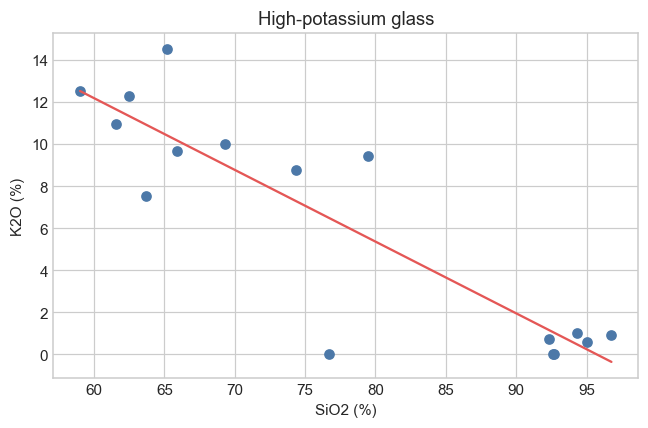

In [25]:
# 教师示例：高钾玻璃中SiO2与K2O的相关性。
high_potassium = artifact_surface.loc[artifact_surface["类型"] == "高钾"]
corr_columns = ["二氧化硅(SiO2)", "氧化钾(K2O)"]
high_complete = high_potassium[corr_columns].dropna()
pearson_high = stats.pearsonr(high_complete[corr_columns[0]], high_complete[corr_columns[1]])
spearman_high = stats.spearmanr(high_complete[corr_columns[0]], high_complete[corr_columns[1]])
print(f"Pearson r={pearson_high.statistic:.3f}, p={pearson_high.pvalue:.3g}")
print(f"Spearman rho={spearman_high.statistic:.3f}, p={spearman_high.pvalue:.3g}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(high_complete[corr_columns[0]], high_complete[corr_columns[1]], color="#4C78A8")
fit = np.polyfit(high_complete[corr_columns[0]], high_complete[corr_columns[1]], deg=1)
x_grid = np.linspace(high_complete[corr_columns[0]].min(), high_complete[corr_columns[0]].max(), 100)
ax.plot(x_grid, np.polyval(fit, x_grid), color="#E45756", linewidth=1.5)
ax.set(title="High-potassium glass", xlabel="SiO2 (%)", ylabel="K2O (%)")
plt.tight_layout()
plt.show()

### 练习7：实现 Pearson 与 Spearman 相关分析

补全 `correlation_significance_test`：成对删除缺失值，根据 `method` 调用 `stats.pearsonr` 或 `stats.spearmanr`，返回配对数、相关系数、p 值和方法。练习使用铅钡玻璃的 PbO 与 BaO。

In [26]:
# UNQ_C7（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: correlation_significance_test
def correlation_significance_test(data, x_column, y_column, method="pearson"):
    """执行Pearson或Spearman相关分析。"""
    # 你的代码从这里开始
    # 第1步：同时选择两列并成对删除缺失值。
    complete_data = ...
    x_values, y_values = ...
    # 第2步：根据method选择相关函数。
    if method == "pearson":
        correlation_result = ...
    elif method == "spearman":
        correlation_result = ...
    else:
        raise ValueError("method必须是'pearson'或'spearman'")
    # 第3步：提取系数和p值。
    coefficient, p_value = ...
    # 第4步：组织返回结果。
    result = {
        "n": len(complete_data), "coefficient": coefficient,
        "p_value": p_value, "method": method,
    }
    # 你的代码到这里结束
    return result

In [27]:
testsuite.test_correlation_significance_test(correlation_significance_test)

测试失败 test_correlation_significance_test：cannot unpack non-iterable ellipsis object


## 8. 多重检验与 Bonferroni 校正

书中指出：同时做很多检验会增加至少出现一次假阳性的机会，这称为 alpha 膨胀。例如 20 个相互独立、原假设都真实的检验在 $\alpha=0.05$ 时，至少一次误报的概率约为 $1-0.95^{20}=0.64$。

书中介绍的 Bonferroni 方法把单次检验阈值改为 $\alpha/m$。等价地，可以计算

$$p_{adjusted}=\min(mp,1),$$

再与原来的 $\alpha$ 比较。该方法简单、保守，适合本章教学中数量不多且事先确定的比较。

In [28]:
# 教师示例：对4种铅钡玻璃成分的Welch t检验p值做Bonferroni校正。
example_components = ["二氧化硅(SiO2)", "氧化钠(Na2O)", "氧化铅(PbO)", "氧化钡(BaO)"]
example_raw_p = {}
for component in example_components:
    group_no = lead_barium.loc[lead_barium["采样面状态"] == "无风化", component]
    group_weathered = lead_barium.loc[lead_barium["采样面状态"] == "风化", component]
    example_raw_p[component] = stats.ttest_ind(group_no, group_weathered, equal_var=False).pvalue
example_raw_p = pd.Series(example_raw_p, name="raw_p_value")
example_adjusted = np.minimum(example_raw_p.to_numpy() * len(example_raw_p), 1.0)
example_multiple = pd.DataFrame({
    "raw_p_value": example_raw_p,
    "adjusted_p_value": example_adjusted,
    "reject": example_adjusted < 0.05,
})
display(example_multiple.sort_values("adjusted_p_value"))

,raw_p_value,adjusted_p_value,reject
二氧化硅(SiO2),1.2634e-10,5.0537e-10,True
氧化铅(PbO),5.2104e-08,2.0841e-07,True
氧化钠(Na2O),1.8967e-02,7.5867e-02,False
氧化钡(BaO),3.3347e-01,1.0000e+00,False


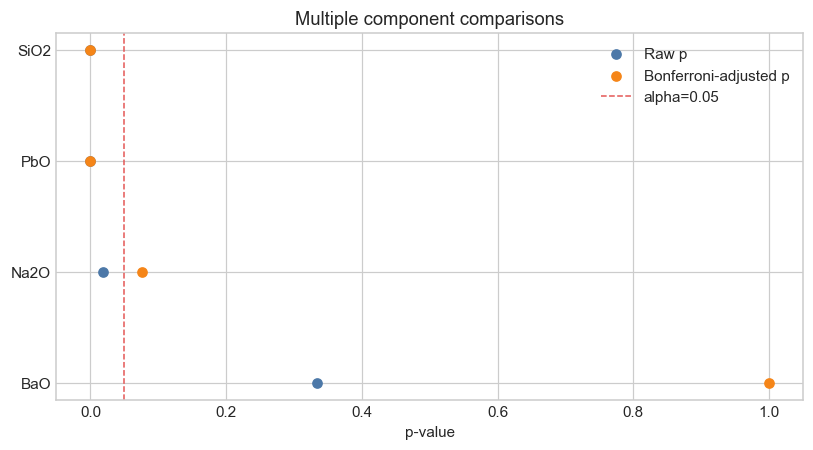

In [29]:
plot_data = example_multiple.sort_values("adjusted_p_value", ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
y = np.arange(len(plot_data))
labels = [name.split("(")[-1].rstrip(")") for name in plot_data.index]
ax.scatter(plot_data["raw_p_value"], y, label="Raw p", color="#4C78A8")
ax.scatter(plot_data["adjusted_p_value"], y, label="Bonferroni-adjusted p", color="#F58518")
ax.axvline(0.05, color="#E45756", linestyle="--", linewidth=1, label="alpha=0.05")
ax.set(yticks=y, yticklabels=labels, xlabel="p-value", title="Multiple component comparisons")
ax.legend()
plt.tight_layout()
plt.show()

### 练习8：实现 Bonferroni 校正

补全 `bonferroni_adjustment`：输入带标签的 p 值 Series，计算 `min(p*m, 1)`，返回原始 p 值、调整后 p 值和显著性标记，并保持索引和顺序。

In [30]:
# UNQ_C8（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: bonferroni_adjustment
def bonferroni_adjustment(p_values, alpha=0.05):
    """对带标签的p值序列执行Bonferroni校正。"""
    # 你的代码从这里开始
    # 第1步：记录比较次数m，并把p值转换为NumPy数组。
    number_of_tests = ...
    raw_p_values = ...
    # 第2步：计算min(p*m, 1)形式的调整后p值。
    adjusted_p_values = ...
    # 第3步：根据调整后p值是否小于alpha生成拒绝标记。
    reject = ...
    # 第4步：保留输入索引，按规定列顺序构造DataFrame。
    result = ...
    # 你的代码到这里结束
    return result

In [31]:
testsuite.test_bonferroni_adjustment(bonferroni_adjustment)

测试失败 test_bonferroni_adjustment：


## 9. 综合练习：回答赛题问题 1 的分类特征关系

赛题问题 1 不只是对一个列联表做检验，而是要把同一套分析流程应用到多个分类特征。完整流程可以拆成六步：

1. **确定分析单位。** `basic` 的一行是一件文物，因此文物之间可作为独立观测；不要直接用一件文物的多个采样点重复计数。
2. **逐个特征构造有效样本。** 对当前特征和结果变量成对删除缺失值。每个特征的缺失情况不同，所以样本量 `n` 也可能不同。
3. **建立列联表。** `pd.crosstab` 的单元格是观测频数，不是比例。行数表示特征水平数，列表示结果类别。
4. **执行 Pearson 卡方独立性检验。** 原假设是“当前特征与结果变量独立”。`stats.chi2_contingency` 同时给出 χ²、自由度、p 值和期望频数。
5. **检查近似条件。** 最小期望频数过小时，卡方近似可能不可靠。此时应在结果中保留 `min_expected` 并谨慎解释；2×2 小计数表可考虑前面介绍的 Fisher 精确检验。
6. **汇总而不是只输出一句显著/不显著。** 至少保留样本量、水平数、χ²、自由度、p 值、最小期望频数和显著性标记，便于核查和写作。

下面的范例与练习 9 使用相同的“循环—列联表—卡方检验—汇总”路线，但研究问题不同：范例只选择**无风化文物**，分析“纹饰、颜色是否与玻璃类型有关”，并把显著性水平设为 `0.10`。练习 9 则使用全部文物，分析“类型、纹饰、颜色是否与表面风化有关”，且使用 `0.05`。

In [32]:
# 综合范例9：在无风化文物中，批量分析分类特征与玻璃类型的关系。
def example_batch_category_tests(data, feature_columns, outcome_column, alpha=0.10):
    """逐个特征执行卡方独立性检验，并返回便于比较的汇总表。"""
    rows = []

    for feature in feature_columns:
        # 每个特征分别成对删除缺失，避免把其他列的缺失误用于筛选。
        complete_data = data[[feature, outcome_column]].dropna()
        observed_table = pd.crosstab(
            complete_data[feature], complete_data[outcome_column]
        )

        chi2_result = stats.chi2_contingency(observed_table)
        rows.append(
            {
                "feature": feature,
                "n": int(observed_table.to_numpy().sum()),
                "levels": observed_table.shape[0],
                "chi2": chi2_result.statistic,
                "dof": chi2_result.dof,
                "p_value": chi2_result.pvalue,
                "min_expected": chi2_result.expected_freq.min(),
                "is_significant": chi2_result.pvalue < alpha,
            }
        )

    return pd.DataFrame(rows).set_index("feature")


# 范例的数据、结果变量、特征列表和alpha均与练习9不同。
unweathered_artifacts = basic.loc[basic["表面风化"] == "无风化"].copy()
category_example = example_batch_category_tests(
    unweathered_artifacts,
    feature_columns=["纹饰", "颜色"],
    outcome_column="类型",
    alpha=0.10,
)
display(category_example.round(4))

# 期望频数过小时，不能只依据p值下结论。
display(
    category_example.loc[
        category_example["min_expected"] < 5,
        ["n", "p_value", "min_expected"],
    ].rename_axis("需要谨慎解释的特征")
)

,n,levels,chi2,dof,p_value,min_expected,is_significant
feature,,,,,,,
纹饰,24,2,0.0000,1,1.0000,5.5,False
颜色,24,7,11.3333,6,0.0786,0.5,True


,n,p_value,min_expected
需要谨慎解释的特征,,,
颜色,24,0.0786,0.5


### 从范例迁移到练习

范例已经展示了循环、成对删除缺失、列联表、卡方检验和结果汇总。练习需要迁移这些步骤，但有三处变化：

- 不再筛选“无风化”子集，而是使用 `basic` 的全部文物；
- 结果变量固定为 `表面风化`，待分析特征由参数 `feature_columns` 给出；
- 返回表必须保持输入特征顺序，并严格使用测试要求的列顺序。

### 练习9：批量分析风化相关因素

补全 `analyze_weathering_factors`。建议按下面顺序完成：

1. 建立空列表，并按 `feature_columns` 的输入顺序循环；
2. 对当前特征与 `表面风化` 成对删除缺失；
3. 用 `pd.crosstab` 构造观测频数表；
4. 调用 `stats.chi2_contingency`；
5. 从结果中提取 χ²、自由度、p 值和最小期望频数；
6. 用 `p_value < alpha` 生成布尔标记；
7. 将各特征结果组织成以特征名为索引的 DataFrame。

返回列顺序必须为 `n`、`levels`、`chi2`、`dof`、`p_value`、`min_expected`、`is_significant`。注意：`n` 是当前列联表中观测频数之和，`levels` 是当前特征在有效数据中的水平数。

In [33]:
# UNQ_C9（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: analyze_weathering_factors
def analyze_weathering_factors(basic, feature_columns, alpha=0.05):
    """批量分析分类特征与表面风化的关系。"""
    # 你的代码从这里开始
    # 第1步：建立列表，并按输入顺序遍历特征。
    rows = []
    for feature in feature_columns:
        # 第2步：成对删除缺失值并建立列联表。
        complete_data = ...
        table = ...
        # 第3步：执行卡方检验。
        chi2_result = ...
        # 第4步：保存样本量、水平数、统计量、p值、最小期望频数和判定。
        rows.append({
            "n": ..., "levels": ..., "chi2": ..., "dof": ...,
            "p_value": ..., "min_expected": ...,
            "is_significant": ...,
        })
    # 第5步：以feature_columns为索引并使用规定列顺序构造结果表。
    result_table = ...
    # 你的代码到这里结束
    return result_table

In [34]:
testsuite.test_analyze_weathering_factors(analyze_weathering_factors)

测试失败 test_analyze_weathering_factors：


In [35]:
if testsuite.test_results.get("test_analyze_weathering_factors"):
    display(analyze_weathering_factors(basic, ["类型", "纹饰", "颜色"]).round(4))

## 10. 综合练习：回答赛题问题 1 的成分差异

赛题问题 1 还要求分析风化前后化学成分含量的差异。一次比较多个成分时，需要把描述统计、Welch t 检验和多重检验校正连成一条完整流程：

1. **先固定总体。** 只在指定玻璃类型内比较，并保留“无风化”和“风化”两种采样面。不同玻璃类型应分别分析，避免类型差异混入风化差异。
2. **每个成分独立处理缺失。** 某一成分缺失不应删除其他成分仍可用的记录，因此要在循环内部调用 `dropna()`。
3. **先报告方向和大小。** 记录两组样本量、两组均值以及 `无风化均值 − 风化均值`。正值表示无风化组均值更高，负值表示风化组均值更高。
4. **使用 Welch t 检验。** `equal_var=False` 不强制两组总体方差相等，并会给出 Welch–Satterthwaite 自由度。
5. **校正多次比较。** 若检验 `m` 个成分，Bonferroni 调整值为 `min(raw_p × m, 1)`。综合结论使用调整后 p 值，原始 p 值保留用于审计。
6. **结合数据设计解释。** 显著差异说明样本中存在统计关联，不自动证明风化是成分变化的唯一原因；小样本和离群值也需要结合前面的图形检查。

下面范例分析**高钾玻璃**的 K₂O、CaO 和 CuO，使用 `alpha=0.10`。练习 10 将改为指定的另一类玻璃和另一组成分，并使用默认 `alpha=0.05`。

In [36]:
# 综合范例10：比较高钾玻璃风化前后的三种成分，并做Bonferroni校正。
def example_compare_components(data, glass_type, components, alpha=0.10):
    """在一个玻璃类型内，对多个成分执行Welch t检验。"""
    subset = data.loc[
        (data["类型"] == glass_type)
        & data["采样面状态"].isin(["无风化", "风化"])
    ]
    rows = []

    for component in components:
        no_weathering = subset.loc[
            subset["采样面状态"] == "无风化", component
        ].dropna()
        weathered = subset.loc[
            subset["采样面状态"] == "风化", component
        ].dropna()

        test_result = stats.ttest_ind(
            no_weathering, weathered, equal_var=False
        )
        rows.append(
            {
                "component": component,
                "n_no_weathering": len(no_weathering),
                "n_weathered": len(weathered),
                "mean_no_weathering": no_weathering.mean(),
                "mean_weathered": weathered.mean(),
                "mean_difference": no_weathering.mean() - weathered.mean(),
                "statistic": test_result.statistic,
                "dof": test_result.df,
                "raw_p_value": test_result.pvalue,
            }
        )

    result = pd.DataFrame(rows).set_index("component")
    number_of_tests = len(result)
    result["adjusted_p_value"] = np.minimum(
        result["raw_p_value"] * number_of_tests, 1.0
    )
    result["is_significant"] = result["adjusted_p_value"] < alpha
    return result


# 范例使用高钾玻璃、三种不同成分和alpha=0.10。
high_potassium_example = example_compare_components(
    artifact_surface,
    glass_type="高钾",
    components=["氧化钾(K2O)", "氧化钙(CaO)", "氧化铜(CuO)"],
    alpha=0.10,
)
display(high_potassium_example.round(4))

print("均值差 > 0：无风化组均值较高；均值差 < 0：风化组均值较高。")
print("综合判断使用 adjusted_p_value，raw_p_value 仅表示单次检验结果。")

,n_no_weathering,n_weathered,mean_no_weathering,mean_weathered,mean_difference,statistic,dof,raw_p_value,adjusted_p_value,is_significant
component,,,,,,,,,,
氧化钾(K2O),10,6,9.5665,0.5433,9.0232,7.1813,9.3811,0.0000,0.0001,True
氧化钙(CaO),10,6,5.7345,0.8700,4.8645,5.2858,9.8630,0.0004,0.0011,True
氧化铜(CuO),10,6,2.4150,1.5617,0.8533,1.3921,13.9436,0.1857,0.5571,False


均值差 > 0：无风化组均值较高；均值差 < 0：风化组均值较高。
综合判断使用 adjusted_p_value，raw_p_value 仅表示单次检验结果。


### 从范例迁移到练习

练习与范例使用相同的批量分析框架，但函数不能写死“高钾”或范例中的三个成分。调用者会通过 `glass_type` 和 `components` 传入新的数据范围。特别注意：

- 结果行必须与 `components` 顺序一致；
- 每个成分的两组样本必须分别删除缺失值；
- `mean_difference` 必须按“无风化减风化”计算；
- Welch 检验必须设置 `equal_var=False`；
- Bonferroni 的比较次数是实际成分数 `len(components)`；
- 显著性由调整后 p 值与 `alpha` 比较，而不是由原始 p 值决定。

### 练习10：比较指定类型玻璃的多种成分

补全 `compare_weathering_components`：

1. 筛选 `glass_type` 以及“无风化/风化”两种采样面；
2. 遍历 `components`，分别取得两组非缺失数值；
3. 计算样本量、均值和方向固定的均值差；
4. 调用 `stats.ttest_ind(..., equal_var=False)`；
5. 先构造包含原始 p 值的结果表；
6. 对整列原始 p 值做 Bonferroni 校正；
7. 增加调整后显著性标记并返回结果表。

返回列顺序必须为 `n_no_weathering`、`n_weathered`、`mean_no_weathering`、`mean_weathered`、`mean_difference`、`statistic`、`dof`、`raw_p_value`、`adjusted_p_value`、`is_significant`。

In [37]:
# UNQ_C10（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: compare_weathering_components
def compare_weathering_components(data, glass_type, components, alpha=0.05):
    """使用Welch t检验和Bonferroni校正比较风化前后的多个成分。"""
    # 你的代码从这里开始
    # 第1步：筛选指定玻璃类型和两种采样面，建立结果列表。
    subset = ...
    rows = []
    # 第2步：遍历成分并取得无风化、风化两组数值。
    for component in components:
        no_weathering = ...
        weathered = ...
        # 第3步：执行Welch t检验并计算两个均值和均值差。
        test_result = ...
        mean_no_weathering = ...
        mean_weathered = ...
        # 第4步：保存单个成分结果。
        rows.append({
            "n_no_weathering": ..., "n_weathered": ...,
            "mean_no_weathering": mean_no_weathering,
            "mean_weathered": mean_weathered,
            "mean_difference": ...,
            "statistic": ..., "dof": ..., "raw_p_value": ...,
        })
    # 第5步：以components为索引构造结果表。
    result_table = ...
    # 第6步：对原始p值做Bonferroni校正并判断显著性。
    adjusted_p_values = ...
    result_table["adjusted_p_value"] = ...
    result_table["is_significant"] = ...
    # 你的代码到这里结束
    return result_table

In [38]:
testsuite.test_compare_weathering_components(compare_weathering_components)

测试失败 test_compare_weathering_components：'ellipsis' object does not support item assignment


In [39]:
if testsuite.test_results.get("test_compare_weathering_components"):
    representative_components = [
        "二氧化硅(SiO2)", "氧化钠(Na2O)", "氧化铅(PbO)", "氧化钡(BaO)"
    ]
    display(compare_weathering_components(
        artifact_surface, "铅钡", representative_components
    ).round(4))

## 11. 综合练习：回答赛题问题 4 的成分相关性

问题 4 要比较不同类别玻璃中化学成分之间的关系。由于一组 `k` 个成分会产生 `k(k-1)/2` 个成分对，这也是一个“循环分析 + 多重校正”的综合任务：

1. **在类型内分析。** 先筛选一种玻璃类型，不能把两种玻璃不同的成分中心混合成一个相关关系。
2. **枚举不重复的成分对。** `combinations(components, 2)` 只产生 `(A, B)`，不会再产生重复的 `(B, A)`，也不会计算 `(A, A)`。
3. **按成分对删除缺失值。** 不同成分对的有效样本量可能不同，所以每行都要报告 `n`。
4. **根据问题选择相关系数。** Pearson 衡量线性关系，对离群值较敏感；Spearman 先转为秩，衡量单调关系，更适合明显非线性或受极端值影响的数据。
5. **同时记录系数和 p 值。** 系数符号表示方向，绝对值表示样本中的关系强弱；p 值检验总体相关为零的原假设。不能把“小 p 值”误写成“强相关”。
6. **对全部成分对统一校正。** Bonferroni 比较次数是实际生成的成分对数量，而不是成分数量。
7. **避免因果解释。** 相关关系不代表一个成分导致另一个成分变化；成分总和接近 100% 还可能带来结构性的负相关。

下面范例在**高钾玻璃**中，对 SiO₂、K₂O、CaO 和 CuO 使用 **Pearson** 相关，并设置 `alpha=0.10`。练习 11 将使用调用者给出的玻璃类型、成分集合和相关方法。

In [40]:
# 综合范例11：在高钾玻璃中枚举成分对并计算Pearson相关。
def example_component_correlations(
    data, glass_type, components, method="pearson", alpha=0.10
):
    """计算类型内的成分对相关，并对全部p值做Bonferroni校正。"""
    subset = data.loc[data["类型"] == glass_type]
    rows = []

    for component_x, component_y in combinations(components, 2):
        complete_data = subset[[component_x, component_y]].dropna()
        x_values = complete_data[component_x]
        y_values = complete_data[component_y]

        if method == "pearson":
            correlation_result = stats.pearsonr(x_values, y_values)
        elif method == "spearman":
            correlation_result = stats.spearmanr(x_values, y_values)
        else:
            raise ValueError("method必须是'pearson'或'spearman'")

        rows.append(
            {
                "component_x": component_x,
                "component_y": component_y,
                "n": len(complete_data),
                "coefficient": correlation_result.statistic,
                "raw_p_value": correlation_result.pvalue,
            }
        )

    result = pd.DataFrame(rows)
    number_of_pairs = len(result)
    result["adjusted_p_value"] = np.minimum(
        result["raw_p_value"] * number_of_pairs, 1.0
    )
    result["is_significant"] = result["adjusted_p_value"] < alpha
    return result


# 4个成分产生4×3/2=6个不重复成分对；练习会更换类型、成分和method。
correlation_example = example_component_correlations(
    artifact_surface,
    glass_type="高钾",
    components=[
        "二氧化硅(SiO2)", "氧化钾(K2O)",
        "氧化钙(CaO)", "氧化铜(CuO)",
    ],
    method="pearson",
    alpha=0.10,
)
display(correlation_example.round(4))

print("成分对数量：", len(correlation_example))
print("每一行的n是该成分对成对删除缺失值后的有效样本量。")

,component_x,component_y,n,coefficient,raw_p_value,adjusted_p_value,is_significant
0,二氧化硅(SiO2),氧化钾(K2O),16,-0.8874,0.0000,0.0000,True
1,二氧化硅(SiO2),氧化钙(CaO),16,-0.8775,0.0000,0.0000,True
2,二氧化硅(SiO2),氧化铜(CuO),16,-0.3874,0.1382,0.8290,False
3,氧化钾(K2O),氧化钙(CaO),16,0.7925,0.0003,0.0015,True
4,氧化钾(K2O),氧化铜(CuO),16,0.1442,0.5941,1.0000,False
5,氧化钙(CaO),氧化铜(CuO),16,0.4211,0.1043,0.6257,False


成分对数量： 6
每一行的n是该成分对成对删除缺失值后的有效样本量。


### 从范例迁移到练习

范例固定使用高钾玻璃和 Pearson；练习必须尊重 `glass_type`、`components`、`method` 和 `alpha` 四个参数，不能把范例参数写进函数。完成时注意：

- 用 `combinations(components, 2)` 保持唯一且可预测的成分对顺序；
- 每个成分对在循环内部执行 `dropna()`；
- `method="pearson"` 与 `method="spearman"` 应分别调用对应函数；
- 不支持的方法要明确抛出 `ValueError`；
- 校正比较次数必须等于结果表行数，即实际成分对数；
- 最终显著性依据调整后 p 值判断。

### 练习11：建立类型内的成分相关结果表

补全 `analyze_component_correlations`：

1. 筛选 `glass_type` 对应的数据；
2. 枚举所有不重复的成分对；
3. 对每个成分对成对删除缺失值并记录样本量；
4. 根据 `method` 计算 Pearson 或 Spearman 系数和原始 p 值；
5. 将所有成分对组织成 DataFrame；
6. 按成分对总数做 Bonferroni 校正；
7. 添加调整后显著性标记并返回。

返回列顺序必须为 `component_x`、`component_y`、`n`、`coefficient`、`raw_p_value`、`adjusted_p_value`、`is_significant`。

In [41]:
# UNQ_C11（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: analyze_component_correlations
def analyze_component_correlations(
    data, glass_type, components, method="spearman", alpha=0.05
):
    """在类型内完成多组成分对的相关分析和Bonferroni校正。"""
    # 你的代码从这里开始
    # 第1步：筛选指定类型并建立结果列表。
    subset = ...
    rows = []
    # 第2步：使用combinations枚举所有成分对，并成对删除缺失值。
    for component_x, component_y in ...:
        complete_data = ...
        x_values, y_values = ...
        # 第3步：根据method执行Pearson或Spearman相关分析。
        if method == "pearson":
            correlation_result = ...
        elif method == "spearman":
            correlation_result = ...
        else:
            raise ValueError("method必须是'pearson'或'spearman'")
        # 第4步：保存当前成分对结果。
        rows.append({
            "component_x": component_x, "component_y": component_y,
            "n": len(complete_data), "coefficient": ...,
            "raw_p_value": ...,
        })
    # 第5步：构造结果表并做Bonferroni校正。
    result_table = ...
    adjusted_p_values = ...
    result_table["adjusted_p_value"] = ...
    result_table["is_significant"] = ...
    # 你的代码到这里结束
    return result_table

In [42]:
testsuite.test_analyze_component_correlations(analyze_component_correlations)

测试失败 test_analyze_component_correlations：'ellipsis' object is not iterable


In [43]:
if testsuite.test_results.get("test_analyze_component_correlations"):
    correlation_components = [
        "二氧化硅(SiO2)", "氧化钠(Na2O)", "氧化铅(PbO)", "氧化钡(BaO)"
    ]
    display(analyze_component_correlations(
        artifact_surface, "铅钡", correlation_components, method="spearman"
    ).round(4))

## Checks

### 方法选择清单

在赛题报告中，可按下面顺序自检：

1. **分析单位是什么？** 文物、采样点还是文物的某种采样面？是否存在伪重复？
2. **变量是什么类型？** 两个分类变量用列联分析；连续变量比较或相关分析要看设计和分布。
3. **样本是否独立？** 同一文物的两个部位必须配对；不同文物才可作为独立组。
4. **前提是否合理？** 检查期望频数、差值分布、离群值、线性/单调关系，而非只看一个诊断 p 值。
5. **有没有多重检验？** 同时检查 14 个成分时应控制 FDR 或族错误率。
6. **结论是否完整？** 报告样本量、统计量、自由度（适用时）、p 值、效应量、图形与局限性。

下面从**已保存的 notebook 文件**重新收集十一个函数并统一评分。请先保存，再运行该单元。未完成的模板得到 0 分是正常现象。

In [44]:
student_grade = testsuite.grade_all_tests(NOTEBOOK_FILE)
print(f"本章自动评分：{student_grade}/100")

正在从 notebook 收集评分函数：/Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例/2022-C题学习指南-02-统计分析与假设检验.ipynb


测试失败 test_simple_independent_t_test：cannot unpack non-iterable ellipsis object
测试失败 test_chi_square_independence：cannot unpack non-iterable ellipsis object
测试失败 test_fisher_exact_independence：cannot unpack non-iterable ellipsis object


测试失败 test_prepare_qq_plot_data：cannot unpack non-iterable ellipsis object
测试失败 test_welch_t_test：cannot unpack non-iterable ellipsis object
测试失败 test_permutation_mean_test：unsupported operand type(s) for +=: 'int' and 'ellipsis'
测试失败 test_correlation_significance_test：cannot unpack non-iterable ellipsis object
测试失败 test_bonferroni_adjustment：
测试失败 test_analyze_weathering_factors：
测试失败 test_compare_weathering_components：'ellipsis' object does not support item assignment
测试失败 test_analyze_component_correlations：'ellipsis' object is not iterable

通过 0 / 11 道练习测试
自动评分成绩：0
本章自动评分：0/100


## Next Steps

完成本章后，可以继续：

1. 把练习 9～11 的结果整理成赛题问题 1 和问题 4 的文字结论；
2. 使用书中介绍的置信区间和 bootstrap 表达估计的不确定性；
3. 使用书中介绍的回归、分类和交叉验证方法处理赛题问题 2、问题 3；
4. 在报告中同时呈现样本量、描述统计、图形、检验结果和实际意义；
5. 对化学成分总和接近 100% 造成的相关性限制保持谨慎，不作因果推断。

## 生成pdf报告

In [ ]:
import importlib
from IPython import get_ipython

# 获取项目根目录
project_root = Path().resolve().parent
sys.path.append(str(project_root / 'tests'))
sys.path.append(str(project_root / 'util'))

import notebook2pdf
importlib.reload(notebook2pdf)

ip = get_ipython()
notebook_file = None
if '__vsc_ipynb_file__' in ip.user_ns:
    notebook_file = ip.user_ns['__vsc_ipynb_file__']

pdf_file = f"2022c-02-统计分析与假设检验.pdf"
notebook2pdf.convert_notebook_to_webpdf(notebook_file, pdf_file)

Notebook to PDF: 100%|██████████| 100/100 [00:04<00:00, 20.38%/s]



成功生成报告文件: 2022c-01-数据预处理.pdf
